# Success Rate by MathML Length (4 Cases)


In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

RESULT_SPECS = [
    {
        "case": "from-Nemeth (Braille -> MathML)",
        "path": "results/from-Nemeth-gemini-3-pro-preview-2473exs-200tests.txt",
        "mathml_field": "expected",
        "braille_field": "test_input",
        "prefer_normalized_section": True,
    },
    {
        "case": "to-Nemeth (MathML -> Braille)",
        "path": "results/to-Nemeth-gemini-3-pro-preview-2473exs-200tests.txt",
        "mathml_field": "test_input",
        "braille_field": "expected",
        "prefer_normalized_section": False,
    },
    {
        "case": "from-UEB (Braille -> MathML)",
        "path": "results/from-ueb-gemini-3-pro-preview-2352exs-200tests.txt",
        "mathml_field": "expected",
        "braille_field": "test_input",
        "prefer_normalized_section": True,
    },
    {
        "case": "to-UEB (MathML -> Braille)",
        "path": "results/to-ueb-gemini-3-pro-preview-2352exs-200tests.txt",
        "mathml_field": "test_input",
        "braille_field": "expected",
        "prefer_normalized_section": False,
    },
]

MATHML_LENGTH_BIN_EDGES = [0, 50, 80, 120, 160, 250, 1000]
BRAILLE_LENGTH_BIN_EDGES = [0, 3, 7, 12, 18, 30, 500]

In [8]:
def first_matching_idx(lines, predicate):
    for idx, line in enumerate(lines):
        if predicate(line):
            return idx
    return None


def parse_rows(filepath: str, prefer_normalized_section: bool):
    """Parse one file and return rows from either first or normalized section."""
    with open(filepath, "r", encoding="utf-8") as f:
        lines = [raw_line.strip() for raw_line in f]

    first_match_idx = first_matching_idx(lines, lambda s: s.startswith("# Match | Test Input") or s.startswith("Match | Test Input"))
    normalized_idx = first_matching_idx(lines, lambda s: s.startswith("# Normalized MathML") or s.startswith("Normalized MathML"))

    # Normalized MathML marker
    if prefer_normalized_section and normalized_idx is not None:
        start_idx = normalized_idx + 1
        section_used = 2
    else:
        start_idx = first_match_idx + 1
        section_used = 1

    # When using section 1 and a normalized marker exists later,
    # stop at that marker to avoid mixing both sections.
    if section_used == 1 and normalized_idx is not None and normalized_idx > start_idx:
        end_idx = normalized_idx
    else:
        end_idx = len(lines)

    rows = []
    for line in lines[start_idx:end_idx]:
        if not line or line.startswith("#"):
            continue
        if line.startswith("✓") or line.startswith("✗"):
            parts = line.split(" | ", 3)
            if len(parts) == 4:
                # Skip malformed pseudo-header rows that sometimes appear as "✗ | Test Input | Expected | ..."
                if parts[1] == "Test Input" and parts[2] == "Expected":
                    continue
                rows.append(
                    {
                        "is_success": parts[0] == "✓",
                        "test_input": parts[1],
                        "expected": parts[2],
                        "computed": parts[3],
                    }
                )

    return rows, section_used


def build_dataframe(specs):
    rows = []

    for spec in specs:
        path = Path(spec["path"])
        selected_rows, section_used = parse_rows(str(path), spec["prefer_normalized_section"])

        if not selected_rows:
            raise ValueError(f"No parseable match rows found in: {path}")

        for result in selected_rows:
            mathml = result[spec["mathml_field"]]
            braille = result[spec["braille_field"]]

            rows.append(
                {
                    "case": spec["case"],
                    "file": str(path),
                    "section_used": section_used,
                    "is_success": result["is_success"],
                    "mathml": mathml,
                    "mathml_length": len(mathml),
                    "braille": braille,
                    "braille_length": len(braille),
                }
            )

    return pd.DataFrame(rows)

In [9]:
df = build_dataframe(RESULT_SPECS)

case_order = [spec["case"] for spec in RESULT_SPECS]

# Sanity check summary per file/case
summary_overall = (
    df.groupby(["case", "file", "section_used"], as_index=False)
      .agg(
          total=("is_success", "size"),
          success_rate=("is_success", "mean"),
          min_mathml_length=("mathml_length", "min"),
          max_mathml_length=("mathml_length", "max"),
          min_braille_length=("braille_length", "min"),
          max_braille_length=("braille_length", "max"),
      )
)
summary_overall["success_rate_pct"] = summary_overall["success_rate"] * 100
display(summary_overall)

,case,file,section_used,total,success_rate,min_mathml_length,max_mathml_length,min_braille_length,max_braille_length,success_rate_pct
0,from-Nemeth (Braille -> MathML),results/from-Nemeth-gemini-3-pro-preview-2473e...,2,200,0.740,23,924,2,155,74.0
1,from-UEB (Braille -> MathML),results/from-ueb-gemini-3-pro-preview-2352exs-...,2,200,0.900,23,927,2,174,90.0
2,to-Nemeth (MathML -> Braille),results/to-Nemeth-gemini-3-pro-preview-2473exs...,1,200,0.535,23,927,2,155,53.5
3,to-UEB (MathML -> Braille),results/to-ueb-gemini-3-pro-preview-2352exs-20...,1,200,0.690,23,927,2,174,69.0


In [10]:
# Shared hardcoded MathML bins across all four cases
df["mathml_length_bin"] = pd.cut(df["mathml_length"], bins=MATHML_LENGTH_BIN_EDGES, include_lowest=True)
mathml_bin_order = list(df["mathml_length_bin"].cat.categories)

mathml_summary_by_bin = (
    df.groupby(["case", "mathml_length_bin"], observed=True)
      .agg(total=("is_success", "size"), success_rate=("is_success", "mean"))
      .reset_index()
)

# Fill missing case/bin combinations so every line uses same x-axis bins
mathml_full_index = pd.MultiIndex.from_product([case_order, mathml_bin_order], names=["case", "mathml_length_bin"])
mathml_summary_by_bin = (
    mathml_summary_by_bin
    .set_index(["case", "mathml_length_bin"])
    .reindex(mathml_full_index)
    .reset_index()
)
mathml_summary_by_bin["success_rate_pct"] = mathml_summary_by_bin["success_rate"] * 100

mathml_bin_sizes = (
    df.groupby("mathml_length_bin", observed=False)
      .size()
      .reindex(mathml_bin_order, fill_value=0)
      .rename("count_total")
      .reset_index()
)
display(mathml_bin_sizes)
display(mathml_summary_by_bin)


,mathml_length_bin,count_total
0,"(-0.001, 50.0]",103
1,"(50.0, 80.0]",149
2,"(80.0, 120.0]",116
3,"(120.0, 160.0]",126
4,"(160.0, 250.0]",190
5,"(250.0, 1000.0]",116


,case,mathml_length_bin,total,success_rate,success_rate_pct
0,from-Nemeth (Braille -> MathML),"(-0.001, 50.0]",24,0.875000,87.500000
1,from-Nemeth (Braille -> MathML),"(50.0, 80.0]",40,0.650000,65.000000
2,from-Nemeth (Braille -> MathML),"(80.0, 120.0]",21,1.000000,100.000000
3,from-Nemeth (Braille -> MathML),"(120.0, 160.0]",28,0.785714,78.571429
4,from-Nemeth (Braille -> MathML),"(160.0, 250.0]",48,0.812500,81.250000
5,from-Nemeth (Braille -> MathML),"(250.0, 1000.0]",39,0.487179,48.717949
6,to-Nemeth (MathML -> Braille),"(-0.001, 50.0]",29,0.517241,51.724138
7,to-Nemeth (MathML -> Braille),"(50.0, 80.0]",41,0.512195,51.219512
8,to-Nemeth (MathML -> Braille),"(80.0, 120.0]",29,0.586207,58.620690
9,to-Nemeth (MathML -> Braille),"(120.0, 160.0]",26,0.576923,57.692308


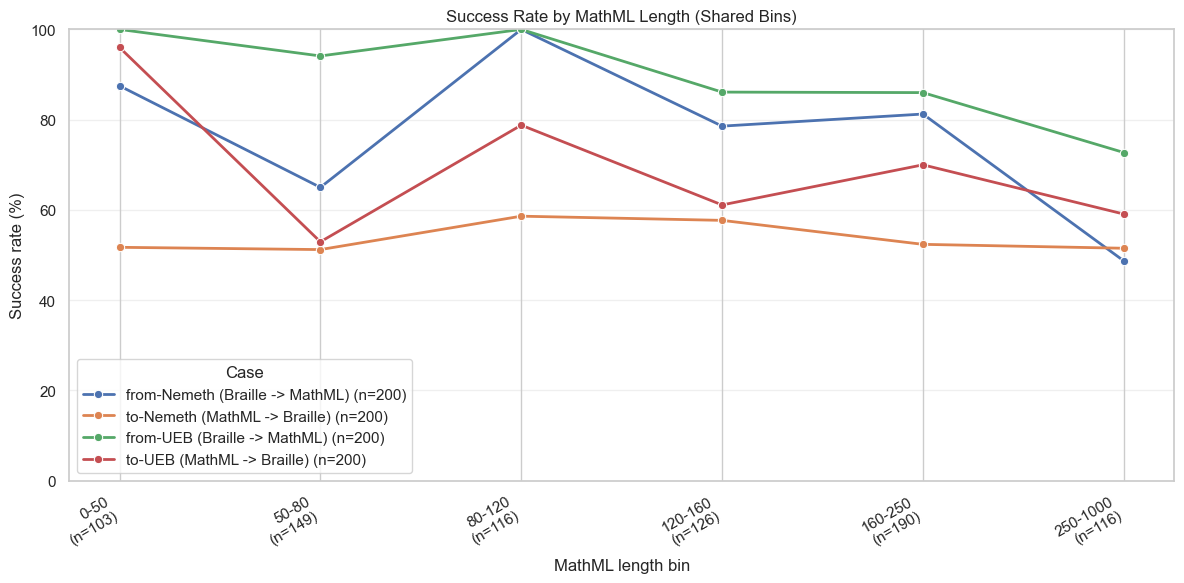

In [11]:
def format_interval(interval) -> str:
    left = int(round(interval.left))
    right = int(round(interval.right))
    return f"{left}-{right}"


x_positions = list(range(len(mathml_bin_order)))
bin_count_map = dict(zip(mathml_bin_sizes["mathml_length_bin"], mathml_bin_sizes["count_total"]))
x_labels = [f"{format_interval(interval)}\n(n={bin_count_map.get(interval, 0)})" for interval in mathml_bin_order]

n_per_case = df.groupby("case").size().to_dict()
mathml_plot_df = mathml_summary_by_bin.copy()
mathml_plot_df["x_pos"] = mathml_plot_df["mathml_length_bin"].map({interval: i for i, interval in enumerate(mathml_bin_order)})
mathml_plot_df["case_label"] = mathml_plot_df["case"].map(lambda c: f"{c} (n={n_per_case[c]})")

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=mathml_plot_df,
    x="x_pos",
    y="success_rate_pct",
    hue="case_label",
    marker="o",
    linewidth=2,
    estimator=None,
    sort=False,
    ax=ax,
)

ax.set_title("Success Rate by MathML Length (Shared Bins)")
ax.set_xlabel("MathML length bin")
ax.set_ylabel("Success rate (%)")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Case")
fig.tight_layout()
plt.show()


# Success Rate by Braille Length (4 Cases)


,braille_length_bin,count_total
0,"(-0.001, 3.0]",128
1,"(3.0, 7.0]",166
2,"(7.0, 12.0]",160
3,"(12.0, 18.0]",182
4,"(18.0, 30.0]",106
5,"(30.0, 500.0]",58


,case,braille_length_bin,total,success_rate,success_rate_pct
0,from-Nemeth (Braille -> MathML),"(-0.001, 3.0]",34,0.882353,88.235294
1,from-Nemeth (Braille -> MathML),"(3.0, 7.0]",47,0.829787,82.978723
2,from-Nemeth (Braille -> MathML),"(7.0, 12.0]",44,0.795455,79.545455
3,from-Nemeth (Braille -> MathML),"(12.0, 18.0]",33,0.787879,78.787879
4,from-Nemeth (Braille -> MathML),"(18.0, 30.0]",23,0.652174,65.217391
5,from-Nemeth (Braille -> MathML),"(30.0, 500.0]",19,0.157895,15.789474
6,to-Nemeth (MathML -> Braille),"(-0.001, 3.0]",34,0.441176,44.117647
7,to-Nemeth (MathML -> Braille),"(3.0, 7.0]",47,0.659574,65.957447
8,to-Nemeth (MathML -> Braille),"(7.0, 12.0]",44,0.431818,43.181818
9,to-Nemeth (MathML -> Braille),"(12.0, 18.0]",33,0.666667,66.666667


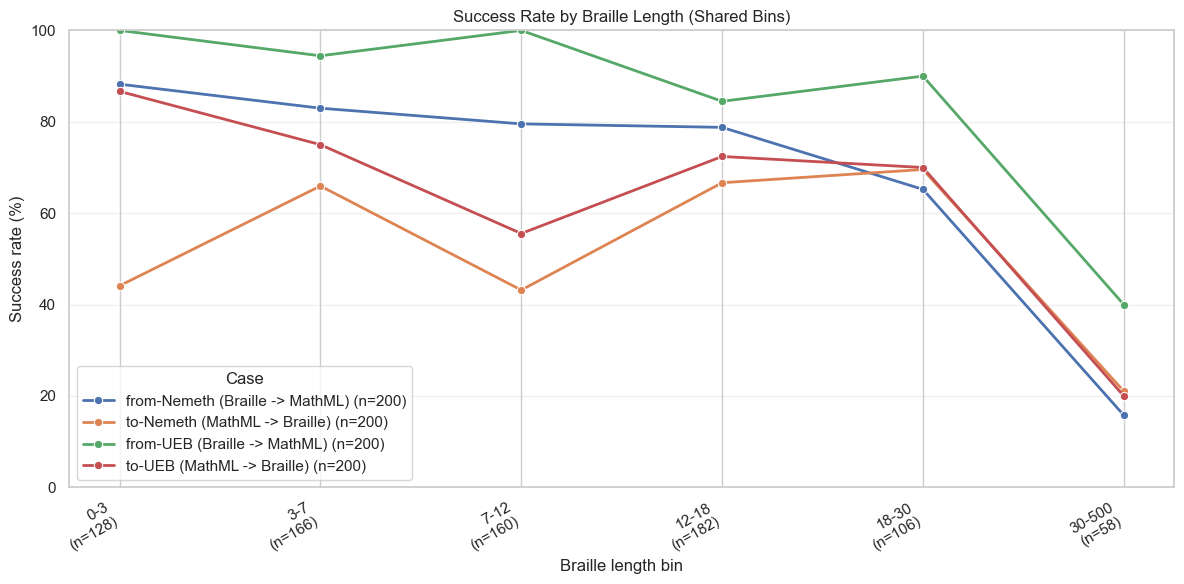

In [12]:
df["braille_length_bin"] = pd.cut(df["braille_length"], bins=BRAILLE_LENGTH_BIN_EDGES, include_lowest=True)
braille_bin_order = list(df["braille_length_bin"].cat.categories)

braille_summary_by_bin = (
    df.groupby(["case", "braille_length_bin"], observed=True)
      .agg(total=("is_success", "size"), success_rate=("is_success", "mean"))
      .reset_index()
)

# Fill missing case/bin combinations so every line uses same x-axis bins
braille_full_index = pd.MultiIndex.from_product([case_order, braille_bin_order], names=["case", "braille_length_bin"])
braille_summary_by_bin = (
    braille_summary_by_bin
    .set_index(["case", "braille_length_bin"])
    .reindex(braille_full_index)
    .reset_index()
)
braille_summary_by_bin["success_rate_pct"] = braille_summary_by_bin["success_rate"] * 100

braille_bin_sizes = (
    df.groupby("braille_length_bin", observed=False)
      .size()
      .reindex(braille_bin_order, fill_value=0)
      .rename("count_total")
      .reset_index()
)
display(braille_bin_sizes)
display(braille_summary_by_bin)

x_positions = list(range(len(braille_bin_order)))
bin_count_map = dict(zip(braille_bin_sizes["braille_length_bin"], braille_bin_sizes["count_total"]))
x_labels = [f"{format_interval(interval)}\n(n={bin_count_map.get(interval, 0)})" for interval in braille_bin_order]

n_per_case = df.groupby("case").size().to_dict()
braille_plot_df = braille_summary_by_bin.copy()
braille_plot_df["x_pos"] = braille_plot_df["braille_length_bin"].map({interval: i for i, interval in enumerate(braille_bin_order)})
braille_plot_df["case_label"] = braille_plot_df["case"].map(lambda c: f"{c} (n={n_per_case[c]})")

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=braille_plot_df,
    x="x_pos",
    y="success_rate_pct",
    hue="case_label",
    marker="o",
    linewidth=2,
    estimator=None,
    sort=False,
    ax=ax,
)

ax.set_title("Success Rate by Braille Length (Shared Bins)")
ax.set_xlabel("Braille length bin")
ax.set_ylabel("Success rate (%)")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Case")
fig.tight_layout()
plt.show()
